# Шаг 3. Предобработка данных: фильтрация, сплит, кодирование признаков

## Цель ноутбука
Подготовить все артефакты, необходимые для обучения моделей в шагах 4–9:
фильтрация холодного старта, временной сплит, ID-мапы, кодирование жанров и тегов,
стандартизация признаков, построение sparse user-item матрицы.

**Ключевой принцип:** все трансформации (fit) — только на train. На val/test — только transform.

## 0. Импорты и настройки

In [1]:
import sys
import warnings
import json
warnings.filterwarnings('ignore')

sys.path.append('..')

from pathlib import Path
import numpy as np
import pandas as pd
import joblib
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from src.utils import SEED, set_seeds
from src.preprocessing import extract_year_from_title, ensure_min_train_per_user

set_seeds()
sns.set_theme(style='whitegrid')

RAW_DIR      = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR   = Path('../models')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"SEED = {SEED}")
print(f"PROCESSED_DIR = {PROCESSED_DIR.resolve()}")
print(f"MODELS_DIR    = {MODELS_DIR.resolve()}")

SEED = 29042005
PROCESSED_DIR = D:\Git-Project\project\data\processed
MODELS_DIR    = D:\Git-Project\project\models


## 1. Загрузка данных

In [2]:
ratings        = pd.read_csv(RAW_DIR / 'ratings.csv')
tags           = pd.read_csv(RAW_DIR / 'tags.csv')
links          = pd.read_csv(RAW_DIR / 'links.csv')
movies_enriched = pd.read_parquet(PROCESSED_DIR / 'movies_enriched.parquet')

print(f"{'Датасет':<22} {'Строки':>10} {'Колонки':>8}")
print("-" * 42)
for name, df in [('ratings', ratings), ('tags', tags),
                 ('links', links), ('movies_enriched', movies_enriched)]:
    print(f"{name:<22} {df.shape[0]:>10,} {df.shape[1]:>8}")

Датасет                    Строки  Колонки
------------------------------------------
ratings                   100,836        4
tags                        3,683        4
links                       9,742        3
movies_enriched             9,742       10


## 2. Фильтрация холодного старта

Фильмы с менее чем 2 оценками и пользователи с менее чем 5 оценками
не дают достаточного сигнала для коллаборативной фильтрации.
Для них в инференсе будет использоваться popularity-фолбэк.

Выполняем итеративную фильтрацию (3 прохода), так как удаление редких фильмов
может сделать редкими некоторых пользователей, и наоборот.

In [3]:
MIN_USER_RATINGS  = 5
MIN_MOVIE_RATINGS = 2

print(f"До фильтрации: {ratings['userId'].nunique()} пользователей, "
      f"{ratings['movieId'].nunique()} фильмов, {len(ratings):,} оценок")

ratings_filtered = ratings.copy()
for i in range(3):
    before = len(ratings_filtered)
    user_counts  = ratings_filtered.groupby('userId').size()
    valid_users  = user_counts[user_counts >= MIN_USER_RATINGS].index
    ratings_filtered = ratings_filtered[ratings_filtered['userId'].isin(valid_users)]

    movie_counts  = ratings_filtered.groupby('movieId').size()
    valid_movies  = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index
    ratings_filtered = ratings_filtered[ratings_filtered['movieId'].isin(valid_movies)]
    after = len(ratings_filtered)
    print(f"  Проход {i+1}: {before:,} -> {after:,} оценок")

summary = pd.DataFrame({
    'Метрика': ['Пользователей', 'Фильмов', 'Оценок'],
    'До фильтрации': [
        ratings['userId'].nunique(),
        ratings['movieId'].nunique(),
        len(ratings),
    ],
    'После фильтрации': [
        ratings_filtered['userId'].nunique(),
        ratings_filtered['movieId'].nunique(),
        len(ratings_filtered),
    ],
})
summary['Сохранено, %'] = (
    summary['После фильтрации'] / summary['До фильтрации'] * 100
).round(1).astype(str) + '%'
display(summary)

До фильтрации: 610 пользователей, 9724 фильмов, 100,836 оценок
  Проход 1: 100,836 -> 97,390 оценок
  Проход 2: 97,390 -> 97,390 оценок
  Проход 3: 97,390 -> 97,390 оценок


,Метрика,До фильтрации,После фильтрации,"Сохранено, %"
0,Пользователей,610,610,100.0%
1,Фильмов,9724,6278,64.6%
2,Оценок,100836,97390,96.6%


## 3. Временной сплит (70% / 15% / 15%)

**Почему временной, а не случайный?**
Временной сплит реалистичнее моделирует реальный сценарий: система обучается
на прошлом и предсказывает будущее. Случайный сплит приводит к data leakage
(будущие оценки «утекают» в обучающую выборку).

In [4]:
ratings_sorted = ratings_filtered.sort_values('timestamp').reset_index(drop=True)
n = len(ratings_sorted)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_raw = ratings_sorted.iloc[:train_end].copy()
val_raw   = ratings_sorted.iloc[train_end:val_end].copy()
test_raw  = ratings_sorted.iloc[val_end:].copy()

print(f"Временная граница train/val: {pd.to_datetime(ratings_sorted.iloc[train_end]['timestamp'], unit='s')}")
print(f"Временная граница val/test:  {pd.to_datetime(ratings_sorted.iloc[val_end]['timestamp'], unit='s')}")
print(f"\nРазмеры до гарантии min_per_user:")
print(f"  train: {len(train_raw):,}")
print(f"  val:   {len(val_raw):,}")
print(f"  test:  {len(test_raw):,}")

Временная граница train/val: 2012-12-22 23:25:42
Временная граница val/test:  2016-10-14 20:15:48

Размеры до гарантии min_per_user:
  train: 68,173
  val:   14,608
  test:  14,609


### Гарантия минимума оценок на пользователя в train

Если пользователь начал ставить оценки поздно, в train их может быть <4.
Переносим его самые ранние оценки из val/test в train.

In [5]:
train, val, test = ensure_min_train_per_user(train_raw, val_raw, test_raw, min_per_user=4)

train_per_user = train.groupby('userId').size()
print(f"Минимум оценок на пользователя в train: {train_per_user.min()}")
print(f"Медиана: {train_per_user.median():.0f}, Макс: {train_per_user.max()}")
print(f"\nРазмеры после гарантии:")
print(f"  train: {len(train):,}")
print(f"  val:   {len(val):,}")
print(f"  test:  {len(test):,}")

Минимум оценок на пользователя в train: 4
Медиана: 41, Макс: 2395

Размеры после гарантии:
  train: 68,829
  val:   14,224
  test:  14,337


## 4. Cold-start защита для val/test

Записи val/test с пользователями или фильмами, которых нет в train,
выделяем в отдельный файл `cold_start_eval.parquet`.
В инференсе для них будет работать popularity-фолбэк.

In [6]:
train_users  = set(train['userId'].unique())
train_movies = set(train['movieId'].unique())

def split_cold(df):
    is_cold = ~df['userId'].isin(train_users) | ~df['movieId'].isin(train_movies)
    return df[~is_cold].copy(), df[is_cold].copy()

val,  val_cold  = split_cold(val)
test, test_cold = split_cold(test)

cold_start_eval = pd.concat(
    [val_cold.assign(split='val'), test_cold.assign(split='test')],
    ignore_index=True
)

size_df = pd.DataFrame({
    'Сплит': ['train', 'val (warm)', 'test (warm)', 'cold_start_eval'],
    'Строк': [len(train), len(val), len(test), len(cold_start_eval)],
    'Пользователей': [
        train['userId'].nunique(), val['userId'].nunique(),
        test['userId'].nunique(), cold_start_eval['userId'].nunique() if len(cold_start_eval) else 0,
    ],
    'Фильмов': [
        train['movieId'].nunique(), val['movieId'].nunique(),
        test['movieId'].nunique(), cold_start_eval['movieId'].nunique() if len(cold_start_eval) else 0,
    ],
})
display(size_df)

,Сплит,Строк,Пользователей,Фильмов
0,train,68829,610,5446
1,val (warm),12289,114,2437
2,test (warm),11728,99,3252
3,cold_start_eval,4544,160,832


## 5. ID-мапы

In [7]:
unique_users  = sorted(train['userId'].unique())
unique_movies = sorted(train['movieId'].unique())

user_id_map      = {orig: idx for idx, orig in enumerate(unique_users)}
movie_id_map     = {orig: idx for idx, orig in enumerate(unique_movies)}
inv_user_id_map  = {v: k for k, v in user_id_map.items()}
inv_movie_id_map = {v: k for k, v in movie_id_map.items()}

for split_df in (train, val, test):
    split_df['user_idx']  = split_df['userId'].map(user_id_map)
    split_df['movie_idx'] = split_df['movieId'].map(movie_id_map)

n_users  = len(user_id_map)
n_movies = len(movie_id_map)
print(f"Уникальных пользователей в train: {n_users}")
print(f"Уникальных фильмов в train:       {n_movies}")

joblib.dump(user_id_map,      MODELS_DIR / 'user_id_map.pkl')
joblib.dump(movie_id_map,     MODELS_DIR / 'movie_id_map.pkl')
joblib.dump(inv_user_id_map,  MODELS_DIR / 'inv_user_id_map.pkl')
joblib.dump(inv_movie_id_map, MODELS_DIR / 'inv_movie_id_map.pkl')
print("ID-мапы сохранены.")

Уникальных пользователей в train: 610
Уникальных фильмов в train:       5446
ID-мапы сохранены.


## 6. Кодирование жанров (MultiLabelBinarizer)

`fit` выполняется **только на фильмах из train**. Если в val/test встретится
новый жанр (маловероятно для MovieLens), он будет проигнорирован — это допустимо.

In [8]:
train_movie_ids = set(train['movieId'].unique())
movies_train_subset = movies_enriched[movies_enriched['movieId'].isin(train_movie_ids)]

mlb = MultiLabelBinarizer()
mlb.fit(movies_train_subset['genres_list'])

joblib.dump(mlb, MODELS_DIR / 'genre_encoder.pkl')
print(f"Жанры (классы MLB): {list(mlb.classes_)}")
print(f"Всего жанров: {len(mlb.classes_)}")

# transform на всех фильмах
genre_full = mlb.transform(movies_enriched['genres_list'])
genre_features = pd.DataFrame(
    genre_full, columns=[f'genre_{g}' for g in mlb.classes_]
)
genre_features.insert(0, 'movieId', movies_enriched['movieId'].values)
print(f"\nЖанровая матрица: {genre_features.shape}")

Жанры (классы MLB): ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Всего жанров: 19

Жанровая матрица: (9742, 20)


## 7. TF-IDF тегов

`fit` выполняется **только на тегах фильмов из train** (`tags_concat` из `movies_enriched`).
Фильмы без тегов имеют пустую строку — TF-IDF корректно даёт им нулевой вектор.

In [9]:
movies_train_tags = movies_enriched[movies_enriched['movieId'].isin(train_movie_ids)]

tfidf = TfidfVectorizer(
    max_features=200,
    min_df=2,
    stop_words='english',
    lowercase=True
)
tfidf.fit(movies_train_tags['tags_concat'].fillna(''))

joblib.dump(tfidf, MODELS_DIR / 'tfidf_tags.pkl')
print(f"TF-IDF словарь: {len(tfidf.vocabulary_)} терминов")

# Применяем ко всем фильмам
tag_matrix = tfidf.transform(movies_enriched['tags_concat'].fillna(''))
sparse.save_npz(PROCESSED_DIR / 'tag_features.npz', tag_matrix)
print(f"Tag-матрица: {tag_matrix.shape}, ненулей: {tag_matrix.nnz:,}")

# Порядок movieId для tag_matrix
tag_movie_order = movies_enriched[['movieId']].copy()
tag_movie_order['tag_row_idx'] = np.arange(len(tag_movie_order))
tag_movie_order.to_parquet(PROCESSED_DIR / 'tag_movie_order.parquet', index=False)
print("Tag-матрица сохранена.")

TF-IDF словарь: 200 терминов
Tag-матрица: (9742, 200), ненулей: 2,430
Tag-матрица сохранена.


## 8. Числовые агрегаты (только из train)

Считаем статистики по фильмам и пользователям **исключительно из train**,
чтобы не допустить утечки информации о val/test.

In [10]:
# Признаки фильмов
movie_stats = train.groupby('movieId').agg(
    movie_n_ratings_train=('rating', 'size'),
    movie_mean_rating_train=('rating', 'mean'),
    movie_std_rating_train=('rating', 'std'),
).reset_index()
movie_stats['movie_std_rating_train'] = movie_stats['movie_std_rating_train'].fillna(0)

# Признаки пользователей
user_stats = train.groupby('userId').agg(
    user_n_ratings_train=('rating', 'size'),
    user_mean_rating_train=('rating', 'mean'),
    user_std_rating_train=('rating', 'std'),
    user_min_ts=('timestamp', 'min'),
    user_max_ts=('timestamp', 'max'),
).reset_index()
user_stats['user_std_rating_train'] = user_stats['user_std_rating_train'].fillna(0)
user_stats['user_active_days_train'] = (
    user_stats['user_max_ts'] - user_stats['user_min_ts']
) / 86400
user_stats = user_stats.drop(columns=['user_min_ts', 'user_max_ts'])

print("Признаки фильмов (train):")
display(movie_stats.describe().round(3))
print("\nПризнаки пользователей (train):")
display(user_stats.describe().round(3))

Признаки фильмов (train):


,movieId,movie_n_ratings_train,movie_mean_rating_train,movie_std_rating_train
count,5446.000,5446.000,5446.000,5446.000
mean,17103.537,12.638,3.304,0.735
std,26569.821,21.480,0.737,0.434
min,1.000,1.000,0.500,0.000
25%,2084.250,2.000,2.875,0.497
50%,4331.000,5.000,3.423,0.758
75%,8947.750,13.000,3.833,1.003
max,177765.000,271.000,5.000,3.182



Признаки пользователей (train):


,userId,user_n_ratings_train,user_mean_rating_train,user_std_rating_train,user_active_days_train
count,610.000,610.000,610.000,610.000,610.000
mean,305.500,112.834,3.737,0.855,154.496
std,176.236,213.696,0.565,0.338,557.898
min,1.000,4.000,1.275,0.000,0.000
25%,153.250,4.000,3.376,0.673,0.002
50%,305.500,41.000,3.750,0.866,0.013
75%,457.750,113.750,4.077,1.054,2.074
max,610.000,2395.000,5.000,2.043,4568.286


## 9. StandardScaler для числовых признаков

Скейлеры обучаются **только на train**. Трансформация val/test — через `transform`.

In [11]:
movie_numeric_cols = ['movie_n_ratings_train', 'movie_mean_rating_train',
                     'movie_std_rating_train', 'movie_year']
user_numeric_cols  = ['user_n_ratings_train', 'user_mean_rating_train',
                     'user_std_rating_train', 'user_active_days_train']

# Добавляем год выпуска к признакам фильмов
movie_features = movie_stats.merge(
    movies_enriched[['movieId', 'year']], on='movieId', how='left'
).rename(columns={'year': 'movie_year'})
year_median = movie_features['movie_year'].median()
movie_features['movie_year'] = movie_features['movie_year'].fillna(year_median)

print(f"Медиана года (для заполнения NaN): {year_median:.0f}")

# Fit скейлеров на train
movie_scaler = StandardScaler()
movie_scaler.fit(movie_features[movie_numeric_cols])
movie_features[movie_numeric_cols] = movie_scaler.transform(movie_features[movie_numeric_cols])

user_scaler = StandardScaler()
user_scaler.fit(user_stats[user_numeric_cols])
user_stats[user_numeric_cols] = user_scaler.transform(user_stats[user_numeric_cols])

joblib.dump(movie_scaler, MODELS_DIR / 'movie_scaler.pkl')
joblib.dump(user_scaler,  MODELS_DIR / 'user_scaler.pkl')
print("Скейлеры сохранены.")

print("\nПризнаки фильмов после стандартизации (mean~0, std~1):")
display(movie_features[movie_numeric_cols].describe().round(3))

Медиана года (для заполнения NaN): 1997
Скейлеры сохранены.

Признаки фильмов после стандартизации (mean~0, std~1):


,movie_n_ratings_train,movie_mean_rating_train,movie_std_rating_train,movie_year
count,5446.000,5446.000,5446.000,5446.000
mean,0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000
min,-0.542,-3.804,-1.696,-4.629
25%,-0.495,-0.582,-0.549,-0.321
50%,-0.356,0.161,0.053,0.286
75%,0.017,0.718,0.617,0.650
max,12.029,2.301,5.643,1.560


## 10. Sparse User-Item матрица (CSR, только train)

In [12]:
rows = train['user_idx'].values
cols = train['movie_idx'].values
data = train['rating'].values.astype(np.float32)

user_item_train = sparse.csr_matrix(
    (data, (rows, cols)), shape=(n_users, n_movies)
)
sparse.save_npz(PROCESSED_DIR / 'user_item_train.npz', user_item_train)

sparsity = 1 - user_item_train.nnz / (n_users * n_movies)
print(f"Размер sparse матрицы: {user_item_train.shape}")
print(f"Ненулевых элементов:   {user_item_train.nnz:,}")
print(f"Разреженность (sparsity): {sparsity:.4%}")
print(f"Размер в памяти (CSR): ~{user_item_train.data.nbytes / 1024:.1f} KB")

Размер sparse матрицы: (610, 5446)
Ненулевых элементов:   68,829
Разреженность (sparsity): 97.9281%
Размер в памяти (CSR): ~268.9 KB


## 11. Сохранение датасетов

In [13]:
keep_cols = ['userId', 'movieId', 'rating', 'timestamp', 'user_idx', 'movie_idx']

train[keep_cols].to_parquet(PROCESSED_DIR / 'train.parquet', index=False)
val[keep_cols].to_parquet(PROCESSED_DIR / 'val.parquet', index=False)
test[keep_cols].to_parquet(PROCESSED_DIR / 'test.parquet', index=False)
cold_start_eval.to_parquet(PROCESSED_DIR / 'cold_start_eval.parquet', index=False)

movie_features.to_parquet(PROCESSED_DIR / 'movie_features.parquet', index=False)
user_stats.to_parquet(PROCESSED_DIR / 'user_features.parquet', index=False)
genre_features.to_parquet(PROCESSED_DIR / 'genre_features.parquet', index=False)

print("Все датасеты сохранены:")
for name in ['train', 'val', 'test', 'cold_start_eval',
             'movie_features', 'user_features', 'genre_features']:
    p = PROCESSED_DIR / f'{name}.parquet'
    print(f"  {name}.parquet: {p.stat().st_size / 1024:.1f} KB")

Все датасеты сохранены:
  train.parquet: 686.9 KB
  val.parquet: 139.6 KB
  test.parquet: 140.7 KB
  cold_start_eval.parquet: 44.8 KB
  movie_features.parquet: 84.2 KB
  user_features.parquet: 22.2 KB
  genre_features.parquet: 87.4 KB


## 12. Метаданные предобработки

In [14]:
preprocessing_meta = {
    'random_state': SEED,
    'min_user_ratings': MIN_USER_RATINGS,
    'min_movie_ratings': MIN_MOVIE_RATINGS,
    'split_strategy': 'temporal_global_quantile',
    'split_ratios': {'train': 0.70, 'val': 0.15, 'test': 0.15},
    'n_users': int(n_users),
    'n_movies': int(n_movies),
    'n_train': int(len(train)),
    'n_val': int(len(val)),
    'n_test': int(len(test)),
    'n_cold_start': int(len(cold_start_eval)),
    'sparsity': float(sparsity),
    'tfidf_max_features': 200,
    'genre_classes': list(mlb.classes_),
}
with open(PROCESSED_DIR / 'preprocessing_meta.json', 'w', encoding='utf-8') as f:
    json.dump(preprocessing_meta, f, ensure_ascii=False, indent=2)

print("preprocessing_meta.json сохранён:")
print(f"  n_users={n_users}, n_movies={n_movies}")
print(f"  train={len(train):,}, val={len(val):,}, test={len(test):,}")
print(f"  cold_start={len(cold_start_eval):,}, sparsity={sparsity:.4%}")

preprocessing_meta.json сохранён:
  n_users=610, n_movies=5446
  train=68,829, val=12,289, test=11,728
  cold_start=4,544, sparsity=97.9281%


## 13. Сводная визуализация

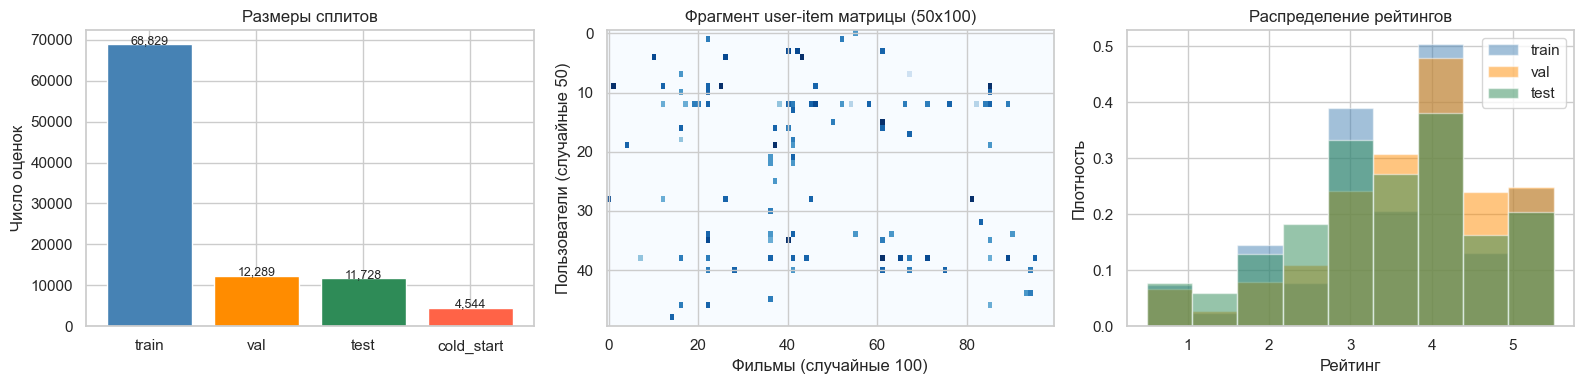

Визуализация сохранена.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Размеры сплитов
split_names = ['train', 'val', 'test', 'cold_start']
split_sizes = [len(train), len(val), len(test), len(cold_start_eval)]
axes[0].bar(split_names, split_sizes, color=['steelblue', 'darkorange', 'seagreen', 'tomato'])
axes[0].set_title('Размеры сплитов')
axes[0].set_ylabel('Число оценок')
for bar, v in zip(axes[0].patches, split_sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{v:,}', ha='center', fontsize=9)

# 2. Фрагмент user-item матрицы (50 users x 100 movies)
rng = np.random.default_rng(SEED)
sample_users  = rng.choice(n_users,  size=min(50, n_users),  replace=False)
sample_movies = rng.choice(n_movies, size=min(100, n_movies), replace=False)
ui_sample = user_item_train[sample_users, :][:, sample_movies].toarray()
axes[1].imshow(ui_sample, aspect='auto', cmap='Blues', interpolation='nearest')
axes[1].set_title(f'Фрагмент user-item матрицы (50x100)')
axes[1].set_xlabel('Фильмы (случайные 100)')
axes[1].set_ylabel('Пользователи (случайные 50)')

# 3. Распределение рейтингов в train/val/test
for split_df, name, color in [(train, 'train', 'steelblue'),
                               (val, 'val', 'darkorange'),
                               (test, 'test', 'seagreen')]:
    axes[2].hist(split_df['rating'], bins=9, density=True, alpha=0.5,
                 label=name, color=color, range=(0.5, 5.5))
axes[2].set_title('Распределение рейтингов')
axes[2].set_xlabel('Рейтинг')
axes[2].set_ylabel('Плотность')
axes[2].legend()

plt.tight_layout()
plt.savefig('preprocessing_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print("Визуализация сохранена.")